In [453]:
import pandas as pd
import os
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [455]:
import warnings
warnings.filterwarnings('ignore')

In [457]:
group = pd.read_csv('/data1/DYY/bambu/288_group.csv',sep='\t')

In [459]:
group.loc[:,'tissue']=group['Sample ID'].str[:3]

In [461]:
tissue = group.tissue.drop_duplicates()

In [475]:
gene_cpm

tissue,BLA,BRE,CER,COL,END,KID,LIV,LUN,REC,STO
BambuGene1,1.00000,0.0,1.0,1.0,3.00000,2.0,1.00000,0.00000,0.00000,0.0
BambuGene1000,14.00000,12.0,4.0,5.0,1.00000,0.0,6.00000,4.00000,1.00000,0.0
BambuGene100001,476.99998,341.0,411.0,486.0,321.99998,382.0,225.00002,308.00003,159.99999,343.0
BambuGene100006,16.00000,9.0,7.0,7.0,3.00000,2.0,2.00000,5.00000,1.00000,5.0
BambuGene100010,128.00000,66.0,85.0,151.0,200.00000,680.0,109.00000,1171.00000,89.00000,134.0
...,...,...,...,...,...,...,...,...,...,...
unstranded.Gene58,8.00000,9.0,5.0,3.0,5.00000,2.0,1.00000,2.00000,3.00000,9.0
unstranded.Gene85,4.00000,7.0,7.0,7.0,7.00000,5.0,2.00000,5.00000,2.00000,7.0
unstranded.Gene88,0.00000,1.0,3.0,2.0,4.00000,1.0,3.00000,0.00000,0.00000,1.0
unstranded.Gene91,3.00000,2.0,0.0,0.0,1.00000,1.0,0.00000,1.00000,0.00000,1.0


In [491]:
combined_df=pd.DataFrame()
CPM = pd.read_csv('/data1/DYY/bambu/counts_gene.csv',sep='\t',index_col=0).T
CPM.loc[:,'tissue'] = CPM['sample'].str[:3]
CPM = CPM.set_index('tissue')
gene_cpm = CPM.drop('sample',axis=1).astype(float).reset_index().groupby('tissue').sum().T
# con_gene = desgene_df.loc[desgene_df.con==1].index.tolist()
# sca_gene = desgene_df.loc[desgene_df.sca==1].index.tolist()
for t in tissue:
    down = pd.read_csv(f'/data1/DYY/bambu/288_count_matrix_deseq2/{t}_fc1_down_reg_genes.csv',sep='\t',index_col=0)
    # df.loc[:,'Organ'] = t
    up = pd.read_csv(f'/data1/DYY/bambu/288_count_matrix_deseq2/{t}_fc1_up_reg_genes.csv',sep='\t',index_col=0)
    try:
        con = pd.read_csv(f'/data1/DYY/bambu/288_conver_scatt_gene_all_tis/{t}_con.txt',header=None)
    except:
        con = pd.DataFrame(columns=[0])
    try:
        sca = pd.read_csv(f'/data1/DYY/bambu/288_conver_scatt_gene_all_tis/{t}_sca.txt',header=None)
    except:
        sca = pd.DataFrame(columns=[0])
    # df = desgene_df.loc[(desgene_df.con==1) | (desgene_df.sca==1)][['con','sca']]
    # df.loc[:,'con'] = np.nan
    # df.loc[:,'sca'] = np.nan
    # con_cpm = gene_cpm.loc[con_gene,t]
    # sca_cpm = gene_cpm.loc[sca_gene,t]
    # con_cpm = con_cpm[con_cpm>0].index.tolist()
    # sca_cpm = sca_cpm[sca_cpm>0].index.tolist()
    # df.loc[gene_cpm.loc[gene_cpm.loc[con_gene,t]>0],t]
    df = pd.DataFrame(index = gene_cpm.index)
    # df.loc[con_cpm,'con'] = 1
    # df.loc[sca_cpm,'sca'] = 1
    df.loc[con[0],'con'] = 1
    df.loc[sca[0],'sca'] = 1
    df.loc[df.index.isin(down.index),'down'] = 1
    df.loc[df.index.isin(up.index),'up'] = 1
    df = df.loc[df.count(axis=1)>0]
    df.loc[:,'Organ'] = t
    
    combined_df = pd.concat([combined_df,df])
    # break

In [582]:
desg  = pd.DataFrame(index=desgene_df.index)
for t in tissue:
    tissue_desg = desgene_df.loc[:,desgene_df.columns.str.contains(t)]
    tissue_desg = tissue_desg.loc[tissue_desg.sum(axis=1)>0]
    desg.loc[tissue_desg.index,t] = 1
    # break

In [592]:
len(desg)

6043

In [594]:
3989/6043

0.6601025980473275

In [62]:
desgene_df = pd.read_csv('/data1/DYY/bambu/288_desgene_df/288samples_alltissue_desg.csv',sep='\t',index_col=0)

# figure s6 

In [519]:
shared = combined_df.reset_index().groupby('index').count()
reshaped_df = shared[['con', 'sca', 'down', 'up']].melt(value_name='Counts')

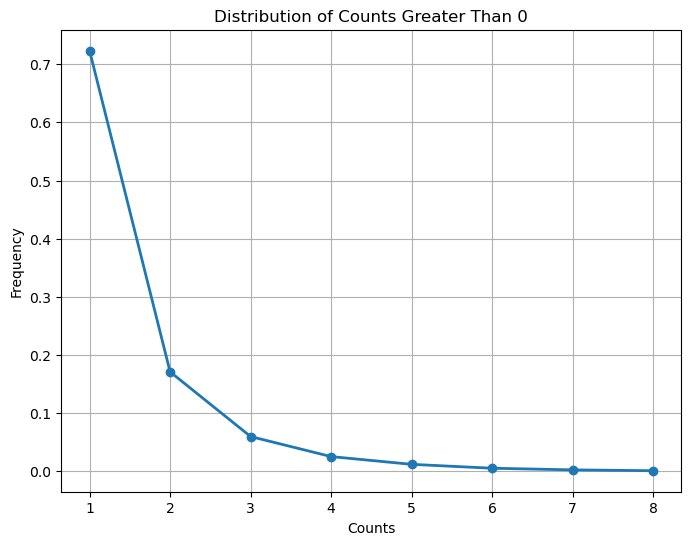

In [537]:
import matplotlib.pyplot as plt

# Filter values where Counts > 0
filtered_df = reshaped_df.loc[reshaped_df['Counts'] > 0]

# Group by 'Counts' to calculate occurrences
line_data = filtered_df['Counts'].value_counts().sort_index()

# Plot the line chart
plt.figure(figsize=(8, 6))
plt.plot(line_data.index, line_data.values/len(filtered_df), marker='o', linestyle='-', linewidth=2)
plt.title('Distribution of Counts Greater Than 0')
plt.xlabel('Counts')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [539]:
tum_spec = pd.read_csv('/data1/DYY/bambu/288_tumor_specific_trans/all_tumor_specific.txt',header=None)

In [551]:
desgene_df = pd.read_csv('/data1/DYY/bambu/s3.csv',sep='\t',index_col=0).iloc[:,:-1]

In [531]:
10806/len(reshaped_df.loc[reshaped_df.Counts>0])

0.7231963592557891

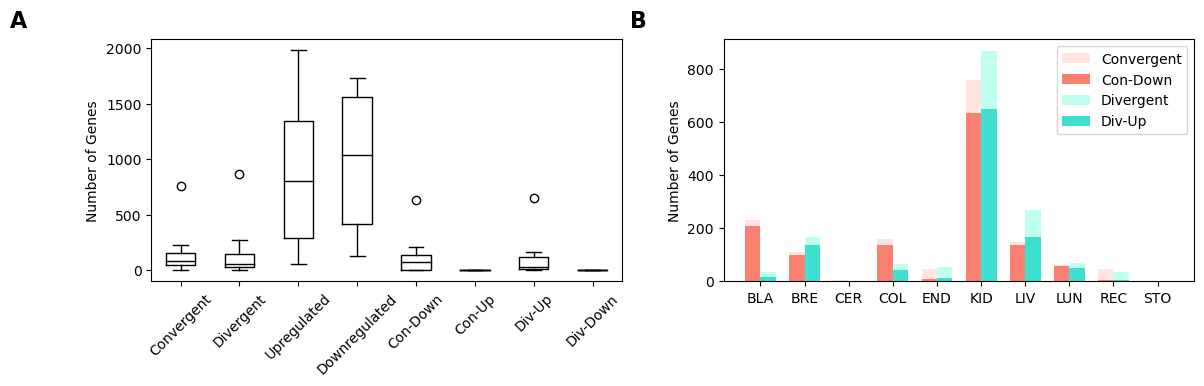

In [616]:
df = combined_df
grouped = df.groupby("Organ").apply(
    lambda x: pd.Series({
        "Convergent": x["con"].notna().sum(),
        "Divergent": x["sca"].notna().sum(),
        "Upregulated": x["up"].notna().sum(),
        "Downregulated": x["down"].notna().sum(),
        "Con-Down": ((x["con"] == 1) & (x["down"] == 1)).sum(),
        "Con-Up":((x['con']==1) & x['up']==1).sum(),
        "Div-Up": ((x["sca"] == 1) & (x["up"] == 1)).sum(),
        'Div-Down':((x['sca']==1) & (x['down']==1)).sum()
    })
)

# 为箱线图准备数据（按列取值）
boxplot_data = [grouped[col].values for col in grouped.columns]
boxplot_labels = grouped.columns

# 定义每个箱线图的颜色
colors = ['blue', 'green', 'red', 'orange', 'purple', 'cyan']

# 创建子图
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 图一：不同颜色的箱线图
boxplots = axes[0].boxplot(boxplot_data, patch_artist=False, medianprops=dict(color="black"))


axes[0].set_xticks(range(1, len(boxplot_labels) + 1))
axes[0].set_xticklabels(boxplot_labels, rotation=45)
# axes[0].set_title("Box Plot for Gene Categories Across Organs")
# axes[0].set_xlabel("Categories")
axes[0].set_ylabel("Number of Genes")
axes[0].text(-0.3, 1.05, 'A', transform=axes[0].transAxes, fontsize=16, fontweight='bold')

# 图二：分组柱状图
bar_data = grouped.reset_index()
x = np.arange(len(bar_data))  # 横坐标
width = 0.35  # 柱子宽度
axes[1].bar(x - width/2, bar_data["Convergent"], width, label="Convergent", color="#FFE4E1")
axes[1].bar(x - width/2, bar_data["Con-Down"], width, label="Con-Down", color="salmon")
axes[1].bar(x + width/2, bar_data["Divergent"], width, label="Divergent", color="#C1FFF0")
axes[1].bar(x + width/2, bar_data["Div-Up"], width, label="Div-Up", color="Turquoise")
axes[1].set_xticks(x)
axes[1].set_xticklabels(bar_data["Organ"])
# axes[1].set_title("Grouped Bar Chart for Gene Categories")
axes[1].set_ylabel("Number of Genes")
axes[1].legend()
axes[1].text(-0.2, 1.05, 'B', transform=axes[1].transAxes, fontsize=16, fontweight='bold')

# 调整布局
plt.tight_layout()
# plt.show()
plt.savefig('/data1/DYY/bambu/plot/1226s6.pdf',dpi=400)

In [598]:
bar_data

,Organ,Convergent,Divergent,Upregulated,Downregulated,Con-Down,Con-Up,Div-Up,Div-Down
0,BLA,229,33,829,1734,208,0,17,0
1,BRE,109,166,1853,1590,97,0,138,0
2,CER,3,0,58,312,2,0,0,0
3,COL,161,64,783,1239,136,0,44,0
4,END,46,53,428,415,7,0,11,0
5,KID,758,869,1978,1473,634,0,650,0
6,LIV,146,270,1371,1643,137,0,166,0
7,LUN,61,68,1250,836,56,0,49,0
8,REC,46,33,244,424,5,0,5,0
9,STO,0,0,152,128,0,0,0,0


In [265]:
desgene_df

,up,down,con,sca
row,,,,
BambuGene100010,1.0,NaN,NaN,NaN
BambuGene100024,NaN,NaN,NaN,1.0
BambuGene100421,1.0,NaN,NaN,NaN
BambuGene100600,NaN,1.0,1.0,NaN
BambuGene100942,NaN,NaN,1.0,NaN
...,...,...,...,...
ENSG00000291115.1,NaN,1.0,NaN,NaN
ENSG00000291116.1,NaN,1.0,NaN,NaN
ENSG00000291164.1,NaN,NaN,1.0,NaN


In [152]:
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap

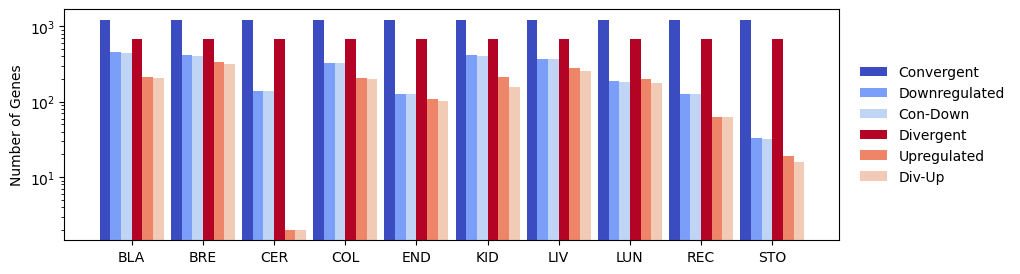

In [249]:
bar_data = grouped.reset_index()
plt.figure(figsize=(10,3))
x = np.arange(len(bar_data))  # 横坐标
width = 0.15  # 柱子宽度
base_cmap = cm.get_cmap('coolwarm')
# 从ocean颜色映射中获取6种等间隔颜色
colors_original = base_cmap(np.linspace(0, 1, 6))
# 创建一个新的离散颜色映射
discrete_cmap = ListedColormap(colors_original)
colors = [discrete_cmap(i) for i in range(6)]

plt.bar(x - width * 5 / 2, bar_data["Convergent"], width, label="Convergent", color=colors[0])
plt.bar(x - width * 3 / 2, bar_data["Downregulated"], width, label="Downregulated", color=colors[1])
plt.bar(x - width / 2, bar_data["Con-Down"], width, label="Con-Down", color=colors[2])

plt.bar(x + width / 2, bar_data["Divergent"], width, label="Divergent", color=colors[5])

plt.bar(x + width * 3 / 2, bar_data["Upregulated"], width, label="Upregulated", color=colors[4])
plt.bar(x + width * 5 / 2, bar_data["Div-Up"], width, label="Div-Up", color=colors[3])
plt.xticks(x, labels=bar_data["Organ"])
# axes[1].set_title("Grouped Bar Chart for Gene Categories")
plt.ylabel("Number of Genes")
plt.legend(loc='center left', bbox_to_anchor=(1.01, 0.5),frameon=False)
# plt.ylim(0,3000)
# plt.text(-0.2, 1.05, 'B', transform=axes[1].transAxes, fontsize=16, fontweight='bold')
# plt.tight_layout()
plt.yscale('log')
# plt.savefig('/data1/DYY/bambu/plot/s6.png',dpi=400,bbox_inches='tight')
plt.show()

In [201]:
bar_data

,Organ,Convergent,Divergent,Upregulated,Downregulated,Con-Down,Div-Up
0,BLA,229,33,829,1734,208,17
1,BRE,109,166,1853,1590,97,138
2,CER,3,0,58,312,2,0
3,COL,161,64,783,1239,136,44
4,END,46,53,428,415,7,11
5,KID,758,869,1978,1473,634,650
6,LIV,146,270,1371,1643,137,166
7,LUN,61,68,1250,836,56,49
8,REC,46,33,244,424,5,5
9,STO,0,0,152,128,0,0


# tables5

In [268]:
s5 = pd.read_csv('/data1/DYY/bambu/s3.csv',sep='\t')

In [300]:
degs[degs.sum(axis=1)>0]

,KID_up,KID_down,KID_con,KID_sca
2,1.0,0.0,0.0,1.0
5,0.0,1.0,0.0,0.0
7,1.0,0.0,0.0,0.0
19,1.0,0.0,0.0,0.0
21,0.0,1.0,0.0,0.0
...,...,...,...,...
6021,0.0,1.0,0.0,0.0
6025,0.0,1.0,0.0,0.0
6031,0.0,1.0,0.0,0.0
6034,1.0,0.0,0.0,1.0


In [302]:
s5df = s5[['GENEID']]
for t in tissue:
    
    degs = s5.loc[:,s5.columns.str.contains(t)]
    s5df.loc[degs[degs.sum(axis=1)>0].index,t]=1
    print(degs.sum(),degs.sum().sum())

BLA_up      273.0
BLA_down    906.0
BLA_con     197.0
BLA_sca      30.0
dtype: float64 1406.0
BRE_up      652.0
BRE_down    572.0
BRE_con      98.0
BRE_sca     145.0
dtype: float64 1467.0
CER_up       42.0
CER_down    222.0
CER_con       3.0
dtype: float64 267.0
COL_up      306.0
COL_down    639.0
COL_con     147.0
COL_sca      58.0
dtype: float64 1150.0
END_up      275.0
END_down    294.0
END_con      38.0
END_sca      45.0
dtype: float64 652.0
STO_up      50.0
STO_down    59.0
dtype: float64 109.0
LIV_up      536.0
LIV_down    594.0
LIV_con     116.0
LIV_sca     255.0
dtype: float64 1501.0
LUN_up      532.0
LUN_down    245.0
LUN_con      50.0
LUN_sca      63.0
dtype: float64 890.0
REC_up      104.0
REC_down    341.0
REC_con      40.0
REC_sca      25.0
dtype: float64 510.0
KID_up      966.0
KID_down    763.0
KID_con     617.0
KID_sca     740.0
dtype: float64 3086.0


/tmp/ipykernel_35498/2745232649.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s5df.loc[degs[degs.sum(axis=1)>0].index,t]=1
/tmp/ipykernel_35498/2745232649.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  s5df.loc[degs[degs.sum(axis=1)>0].index,t]=1
/tmp/ipykernel_35498/2745232649.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pan

In [284]:
len(s5)

6043

In [314]:
most = 

In [322]:
s5.loc[s5.GENEID.isin(s5df.set_index('GENEID').loc[s5df.set_index('GENEID').sum(axis=1)>=8].index.tolist())]

,GENEID,BLA_up,BLA_down,BLA_con,BLA_sca,BRE_up,BRE_down,BRE_con,BRE_sca,CER_up,...,LUN_sca,REC_up,REC_down,REC_con,REC_sca,KID_up,KID_down,KID_con,KID_sca,gene_name
179,ENSG00000175063.17,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,UBE2C
222,ENSG00000170373.9,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,CST1
1606,ENSG00000183287.15,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,CCBE1
3610,ENSG00000167434.10,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,CA4


In [332]:
s5.loc[s5.gene_name=='SPC25'].sum()[1:-1].sum()

4.0

In [334]:
s5.loc[(s5.BLA_down==1) & (s5.BRE_down==1)]

,GENEID,BLA_up,BLA_down,BLA_con,BLA_sca,BRE_up,BRE_down,BRE_con,BRE_sca,CER_up,...,LUN_sca,REC_up,REC_down,REC_con,REC_sca,KID_up,KID_down,KID_con,KID_sca,gene_name
274,ENSG00000170276.6,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,HSPB2
288,ENSG00000160801.14,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,PTH1R
315,ENSG00000175785.13,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,PRIMA1
327,ENSG00000179388.9,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,EGR3
328,ENSG00000179094.16,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,PER1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5924,ENSG00000162733.19,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,DDR2
5946,ENSG00000289884.1,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,ENSG00000289884
5951,ENSG00000104213.13,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,PDGFRL
5989,ENSG00000071991.9,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,CDH19


In [338]:
s5df = s5df.set_index('GENEID')

In [366]:
intersection_df = pd.DataFrame(index=tissue,columns=tissue)
intersection_up_df = intersection_df.copy()
intersection_down_df = intersection_df.copy()
for t1 in tissue:
    for t2 in tissue:
        if t1!=t2:
            intersection =len(s5df.loc[(s5df[t1]==1) & (s5df[t2]==1)])
            intersection_df.loc[t1,t2]=intersection
            intersection_up_df.loc[t1,t2] = len(s5.loc[(s5[f'{t1}_up']==1) & (s5[f'{t2}_up']==1)])
            intersection_down_df.loc[t1,t2] = len(s5.loc[(s5[f'{t1}_down']==1) & (s5[f'{t2}_down']==1)])

In [372]:
intersection_up_df.max().max()

165

In [374]:
intersection_down_df.max().max()

250

In [382]:
s5.loc[(s5.BLA_sca==1) & (s5.BRE_sca==1)]

,GENEID,BLA_up,BLA_down,BLA_con,BLA_sca,BRE_up,BRE_down,BRE_con,BRE_sca,CER_up,...,LUN_sca,REC_up,REC_down,REC_con,REC_sca,KID_up,KID_down,KID_con,KID_sca,gene_name


In [376]:
intersection_df.m().m()

387

In [378]:
intersection_df

Sample ID,BLA,BRE,CER,COL,END,STO,LIV,LUN,REC,KID
Sample ID,,,,,,,,,,
BLA,NaN,387,154,297,190,12,185,122,128,202
BRE,387,NaN,73,219,156,23,270,158,84,284
CER,154,73,NaN,97,62,1,43,34,63,31
COL,297,219,97,NaN,128,24,138,144,241,170
END,190,156,62,128,NaN,10,125,72,56,120
STO,12,23,1,24,10,NaN,25,22,16,39
LIV,185,270,43,138,125,25,NaN,166,80,307
LUN,122,158,34,144,72,22,166,NaN,65,174
REC,128,84,63,241,56,16,80,65,NaN,101
